# REINFORCE Algorithm

In [22]:
!pip install gymnasium torch matplotlib

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [23]:
env = gym.make("Pendulum-v1")  # Continuous action space

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

In [24]:
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
        )
        self.mean = nn.Linear(128, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))  # Learnable std

    def forward(self, x):
        x = self.fc(x)
        mean = self.mean(x)
        std = torch.exp(self.log_std)
        return mean, std

policy = Policy()
optimizer = optim.Adam(policy.parameters(), lr=0.001)

In [25]:
def train(episodes=100):
    reward_history = []

    for ep in range(episodes):
        state, _ = env.reset()
        log_probs = []
        rewards = []

        while True:
            state_tensor = torch.tensor(state, dtype=torch.float32)
            mean, std = policy(state_tensor)

            dist = torch.distributions.Normal(mean, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum()

            action_clipped = action.detach().numpy()
            next_state, reward, done, truncated, _ = env.step(action_clipped)

            log_probs.append(log_prob)
            rewards.append(reward)

            state = next_state

            if done or truncated:
                break

        # Compute returns (Gt)
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + 0.99 * G
            returns.insert(0, G)

        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Policy update
        loss = 0
        for log_prob, G in zip(log_probs, returns):
            loss += -log_prob * G

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        reward_history.append(total_reward)

        print(f"Episode {ep+1}, Reward: {total_reward:.2f}")

    return reward_history

In [26]:
rewards = train(episodes=100)

Episode 1, Reward: -1373.35
Episode 2, Reward: -917.53
Episode 3, Reward: -1122.78
Episode 4, Reward: -1799.32
Episode 5, Reward: -1046.53
Episode 6, Reward: -1175.47
Episode 7, Reward: -1502.33
Episode 8, Reward: -1178.71
Episode 9, Reward: -1223.71
Episode 10, Reward: -1228.67
Episode 11, Reward: -1286.10
Episode 12, Reward: -1262.78
Episode 13, Reward: -1543.49
Episode 14, Reward: -1666.79
Episode 15, Reward: -1679.84
Episode 16, Reward: -1481.50
Episode 17, Reward: -1764.06
Episode 18, Reward: -1142.78
Episode 19, Reward: -1217.71
Episode 20, Reward: -1097.76
Episode 21, Reward: -1822.95
Episode 22, Reward: -1543.12
Episode 23, Reward: -1451.21
Episode 24, Reward: -1646.00
Episode 25, Reward: -1626.81
Episode 26, Reward: -1499.27
Episode 27, Reward: -1665.26
Episode 28, Reward: -1774.98
Episode 29, Reward: -1784.48
Episode 30, Reward: -1230.27
Episode 31, Reward: -1270.20
Episode 32, Reward: -1705.77
Episode 33, Reward: -1684.20
Episode 34, Reward: -1494.80
Episode 35, Reward: -160

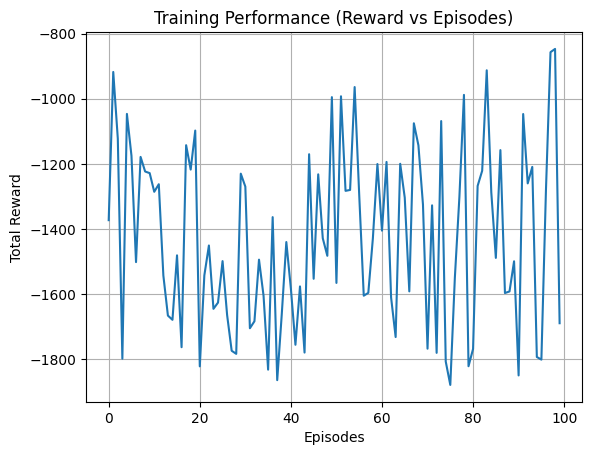

In [27]:
plt.plot(rewards)
plt.title("Training Performance (Reward vs Episodes)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.grid()
plt.show()